# iNOUE MODEL 2014

In [1]:
import numpy as np

# Constants
lambda_L = 911.75  # Lyman limit wavelength in Angstrom

lambda_j = np.array([
    1215.67, 1025.72, 972.537, 949.743, 937.803, 930.748, 926.226,
    923.150, 920.963, 919.352, 918.129, 917.181, 916.429, 915.824,
    915.329, 914.919, 914.576, 914.286, 914.039, 913.826, 913.641,
    913.480, 913.339, 913.215, 913.104, 913.006, 912.918, 912.839,
    912.768, 912.703, 912.645, 912.592, 912.543, 912.499, 912.458,
    912.420, 912.385, 912.353, 912.324
])

ALAF1 = np.array([
    1.690e-02, 4.692e-03, 2.239e-03, 1.319e-03, 8.707e-04, 6.178e-04,
    4.609e-04, 3.569e-04, 2.843e-04, 2.318e-04, 1.923e-04, 1.622e-04,
    1.385e-04, 1.196e-04, 1.043e-04, 9.174e-05, 8.128e-05, 7.251e-05,
    6.505e-05, 5.868e-05, 5.319e-05, 4.843e-05, 4.427e-05, 4.063e-05,
    3.738e-05, 3.454e-05, 3.199e-05, 2.971e-05, 2.766e-05, 2.582e-05,
    2.415e-05, 2.263e-05, 2.126e-05, 2.000e-05, 1.885e-05, 1.779e-05,
    1.682e-05, 1.593e-05, 1.510e-05
])

ALAF2 = np.array([
    2.354e-03, 6.536e-04, 3.119e-04, 1.837e-04, 1.213e-04, 8.606e-05,
    6.421e-05, 4.971e-05, 3.960e-05, 3.229e-05, 2.679e-05, 2.259e-05,
    1.929e-05, 1.666e-05, 1.453e-05, 1.278e-05, 1.132e-05, 1.010e-05,
    9.062e-06, 8.174e-06, 7.409e-06, 6.746e-06, 6.167e-06, 5.660e-06,
    5.207e-06, 4.811e-06, 4.456e-06, 4.139e-06, 3.853e-06, 3.596e-06,
    3.364e-06, 3.153e-06, 2.961e-06, 2.785e-06, 2.625e-06, 2.479e-06,
    2.343e-06, 2.219e-06, 2.103e-06
])

ALAF3 = np.array([
    1.026e-04, 2.849e-05, 1.360e-05, 8.010e-06, 5.287e-06, 3.752e-06,
    2.799e-06, 2.167e-06, 1.726e-06, 1.407e-06, 1.168e-06, 9.847e-07,
    8.410e-07, 7.263e-07, 6.334e-07, 5.571e-07, 4.936e-07, 4.403e-07,
    3.950e-07, 3.563e-07, 3.230e-07, 2.941e-07, 2.689e-07, 2.467e-07,
    2.270e-07, 2.097e-07, 1.943e-07, 1.804e-07, 1.680e-07, 1.568e-07,
    1.466e-07, 1.375e-07, 1.291e-07, 1.214e-07, 1.145e-07, 1.080e-07,
    1.022e-07, 9.673e-08, 9.169e-08
])

ADLA1 = np.array([
    1.617e-04, 1.545e-04, 1.498e-04, 1.460e-04, 1.429e-04, 1.402e-04,
    1.377e-04, 1.355e-04, 1.335e-04, 1.316e-04, 1.298e-04, 1.281e-04,
    1.265e-04, 1.250e-04, 1.236e-04, 1.222e-04, 1.209e-04, 1.197e-04,
    1.185e-04, 1.173e-04, 1.162e-04, 1.151e-04, 1.140e-04, 1.130e-04,
    1.120e-04, 1.110e-04, 1.101e-04, 1.091e-04, 1.082e-04, 1.073e-04,
    1.065e-04, 1.056e-04, 1.048e-04, 1.040e-04, 1.032e-04, 1.024e-04,
    1.017e-04, 1.009e-04, 1.002e-04
])

ADLA2 = np.array([
    5.390e-05, 5.151e-05, 4.992e-05, 4.868e-05, 4.763e-05, 4.672e-05,
    4.590e-05, 4.516e-05, 4.448e-05, 4.385e-05, 4.326e-05, 4.271e-05,
    4.218e-05, 4.168e-05, 4.120e-05, 4.075e-05, 4.031e-05, 3.989e-05,
    3.949e-05, 3.910e-05, 3.872e-05, 3.836e-05, 3.800e-05, 3.766e-05,
    3.732e-05, 3.700e-05, 3.668e-05, 3.637e-05, 3.607e-05, 3.578e-05,
    3.549e-05, 3.521e-05, 3.493e-05, 3.466e-05, 3.440e-05, 3.414e-05,
    3.389e-05, 3.364e-05, 3.339e-05
])

def tau_LS_inoue(wave, z_s):
    """Calculate Lyman series optical depth from Inoue+2014"""
    wave = np.asarray(wave)
    tau = np.zeros(wave.shape, dtype=float)
    
    for j in range(len(lambda_j)):
        z_j = wave / lambda_j[j] - 1.0
        mask = (z_j > 0) & (z_j < z_s)
        
        zj = z_j[mask]
        
        if len(zj) == 0:
            continue
            
        # LAF contribution
        laf = np.zeros_like(zj)
        laf[zj < 1.2] = ALAF1[j] * (1 + zj[zj < 1.2])**1.2
        mask2 = (zj >= 1.2) & (zj < 4.7)
        laf[mask2] = ALAF2[j] * (1 + zj[mask2])**3.7
        laf[zj >= 4.7] = ALAF3[j] * (1 + zj[zj >= 4.7])**5.5
        
        # DLA contribution
        dla = np.zeros_like(zj)
        dla[zj < 2.0] = ADLA1[j] * (1 + zj[zj < 2.0])**2.0
        dla[zj >= 2.0] = ADLA2[j] * (1 + zj[zj >= 2.0])**3.0
        
        tau[mask] += laf + dla
    
    return tau

def tau_LC_inoue(wave, z_s):
    """Calculate Lyman continuum optical depth from Inoue+2014"""
    wave = np.asarray(wave)
    tau = np.zeros(wave.shape, dtype=float)
    
    # FIXED: LC absorption only for λ_obs < λ_L * (1 + z_s)
    # AND λ_obs > λ_L (since photons below rest-frame Lyman limit don't exist)
    mask = (wave < lambda_L * (1 + z_s)) & (wave > lambda_L)
    
    if not np.any(mask):
        return tau
    
    x = wave[mask] / lambda_L
    
    # ---- LAF component ----
    tau_LAF = np.zeros_like(x)
    
    # Since z_s = 6.9 >= 4.7, we use equation (27)
    # For LAF at z_s >= 4.7
    mask1 = x < 2.2
    mask2 = (x >= 2.2) & (x < 5.7)
    mask3 = (x >= 5.7) & (x < (1 + z_s))
    
    if np.any(mask1):
        x1 = x[mask1]
        tau_LAF[mask1] = (5.22e-4 * (1 + z_s)**3.4 * x1**2.1 + 
                         0.325 * x1**1.2 - 3.14e-2 * x1**2.1)
    
    if np.any(mask2):
        x2 = x[mask2]
        tau_LAF[mask2] = (5.22e-4 * (1 + z_s)**3.4 * x2**2.1 + 
                         0.218 * x2**2.1 - 2.55e-2 * x2**3.7)
    
    if np.any(mask3):
        x3 = x[mask3]
        tau_LAF[mask3] = 5.22e-4 * ((1 + z_s)**3.4 * x3**2.1 - x3**5.5)
    
    # ---- DLA component ----
    tau_DLA = np.zeros_like(x)
    
    # Since z_s = 6.9 >= 2.0, we use equation (29)
    # For DLA at z_s >= 2.0
    mask1 = x < 3.0
    mask2 = (x >= 3.0) & (x < (1 + z_s))
    
    if np.any(mask1):
        x1 = x[mask1]
        tau_DLA[mask1] = (0.634 + 4.70e-2 * (1 + z_s)**3.0 - 
                        1.78e-2 * (1 + z_s)**3.3 * x1**(-0.3) - 
                        0.135 * x1**2.0 - 0.291 * x1**(-0.3))
    
    if np.any(mask2):
        x2 = x[mask2]
        tau_DLA[mask2] = (4.70e-2 * (1 + z_s)**3.0 - 
                        1.78e-2 * (1 + z_s)**3.3 * x2**(-0.3) - 
                        2.92e-2 * x2**3.0)
    
    tau[mask] = tau_LAF + tau_DLA
    
    return tau

def total_tau_inoue(wave, z_s):
    """
    Calculate total IGM optical depth (LS + LC) from Inoue+2014
    
    Parameters
    ----------
    wave : array_like
        Observed wavelength(s) in Angstrom
    z_s : float
        Source redshift
    
    Returns
    -------
    tau : array_like
        Total optical depth at each wavelength
    """
    # LS absorption applies everywhere
    tau_ls = tau_LS_inoue(wave, z_s)
    
    # FIXED: LC absorption only applies for λ_obs < λ_L * (1 + z_s)
    tau_lc = np.zeros(wave.shape, dtype=float)
    mask_lc = wave < lambda_L * (1 + z_s)
    if np.any(mask_lc):
        tau_lc[mask_lc] = tau_LC_inoue(wave[mask_lc], z_s)
    
    return tau_ls + tau_lc

def transmission_inoue(wave, z_s):
    """
    Calculate IGM transmission: exp(-tau_total)
    
    Parameters
    ----------
    wave : array_like
        Observed wavelength(s) in Angstrom
    z_s : float
        Source redshift
    
    Returns
    -------
    transmission : array_like
        Transmission fraction at each wavelength
    """
    tau_total = total_tau_inoue(wave, z_s)
    return np.exp(-tau_total)



In [2]:
def inoue_igm_model(wave, z_s, output="transmission"):
    """
     wrapper for the Inoue+2014 IGM absorption model.

    Parameters
    ----------
    wave : array_like
        Observed wavelength(s) in Angstrom.
    z_s : float
        Source redshift.
    output : {"transmission", "tau", "tau_ls", "tau_lc"}
        Quantity to return.

    Returns
    -------
    array_like
        Requested IGM quantity.
    """
    wave = np.asarray(wave)

    if output == "transmission":
        return transmission_inoue(wave, z_s)

    elif output == "tau":
        return total_tau_inoue(wave, z_s)

    elif output == "tau_ls":
        return tau_LS_inoue(wave, z_s)

    elif output == "tau_lc":
        return tau_LC_inoue(wave, z_s)

    else:
        raise ValueError(
            "output must be one of: "
            "'transmission', 'tau', 'tau_ls', 'tau_lc'"
        )


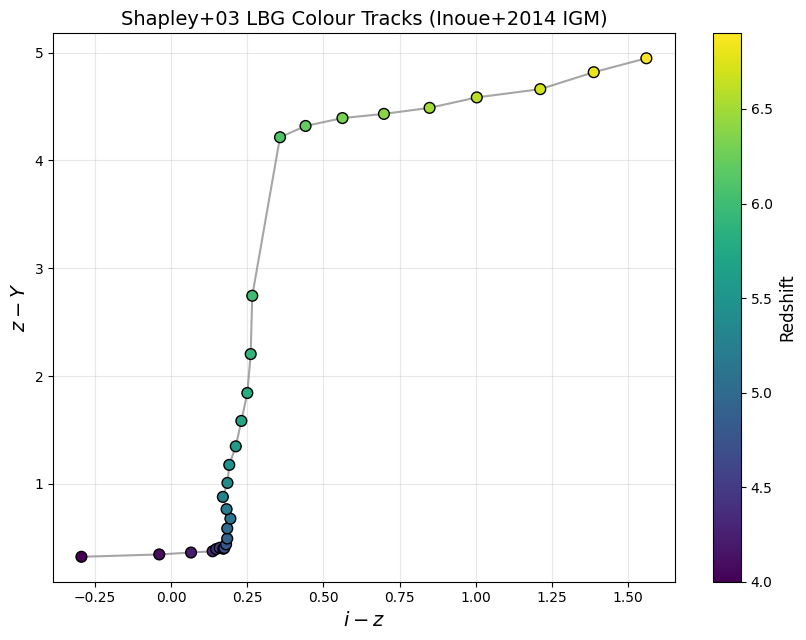

<Figure size 850x650 with 0 Axes>

<Figure size 850x650 with 0 Axes>

In [3]:
import numpy as np
import matplotlib.pyplot as plt

from synphot import SourceSpectrum, SpectralElement, Observation
from synphot.models import Empirical1D
from astropy import units as u

# ============================================================
# 1. LOAD SHAPLEY+03 LBG COMPOSITE
# ============================================================
def load_shapley_spectrum(filename):
    w, f = [], []

    with open(filename) as file:
        for line in file:
            line = line.strip()
            if not line:
                continue
            if "wave" in line.lower() or "lambda" in line.lower():
                continue

            parts = line.replace(",", ".").split()
            if len(parts) < 2:
                continue

            try:
                w.append(float(parts[0]))
                f.append(float(parts[1]))
            except ValueError:
                continue

    w = np.array(w)
    f = np.array(f)

    good = (f > 0) & np.isfinite(f)
    w = w[good]
    f = f[good]

    idx = np.argsort(w)
    return w[idx], f[idx]


wave_rest, flux_rest = load_shapley_spectrum(
    "/Users/aishwarya/Downloads/shapely_spectrum.txt"
)

# ============================================================
# 2. LOAD DECam FILTERS
# ============================================================
def synphot_filter(filename):
    w, t = np.loadtxt(filename, unpack=True)
    idx = np.argsort(w)

    return SpectralElement(
        Empirical1D,
        points=w[idx] * u.AA,
        lookup_table=t[idx]
    )


f_i = synphot_filter("/Users/aishwarya/Downloads/CTIO_DECam.i.dat")
f_z = synphot_filter("/Users/aishwarya/Downloads/CTIO_DECam.z.dat")
f_y = synphot_filter("/Users/aishwarya/Downloads/CTIO_DECam.Y.dat")

# ============================================================
# 3. SYNTHETIC AB MAG
# ============================================================
def synthetic_mag(source, filt):
    obs = Observation(source, filt, force="taper")
    return obs.effstim("abmag").value

# ============================================================
# 4. APPLY INOUE+2013 IGM
# ============================================================
def apply_inoue_igm(w_obs, flux_obs, z):
    T_igm = inoue_igm_model(w_obs, z, output="transmission")
    return flux_obs * T_igm

# ============================================================
# 5. COLOUR TRACK WITH NON-DETECTIONS
# ============================================================
def colour_track(z_vals, maglim_i=27.5):

    i_mags, z_mags, y_mags = [], [], []

    wmin = min(f_i.waveset.min(),
               f_z.waveset.min(),
               f_y.waveset.min()).value
    wmax = max(f_i.waveset.max(),
               f_z.waveset.max(),
               f_y.waveset.max()).value

    w_obs = np.linspace(wmin - 500, wmax + 500, 8000)

    for z in z_vals:

        w_rest_z = w_obs / (1 + z)
        flux_rest_z = np.interp(
            w_rest_z, wave_rest, flux_rest, left=0, right=0
        )

        flux_obs = flux_rest_z / (1 + z)

        flux_igm = apply_inoue_igm(w_obs, flux_obs, z)

        src = SourceSpectrum(
            Empirical1D,
            points=w_obs * u.AA,
            lookup_table=flux_igm * u.Unit("erg s-1 cm-2 AA-1")
        )

        mi = synthetic_mag(src, f_i)
        mz = synthetic_mag(src, f_z)
        my = synthetic_mag(src, f_y)

        mi = max(mi, maglim_i)

        i_mags.append(mi)
        z_mags.append(mz)
        y_mags.append(my)

    return np.array(i_mags), np.array(z_mags), np.array(y_mags)

# ============================================================
# 6. RUN & PLOT WITH REDSHIFT COLORBAR
# ============================================================
z_vals = np.linspace(4.0, 6.9, 30)

i_m, z_m, y_m = colour_track(z_vals)

x = i_m - z_m
y = z_m - y_m

plt.figure(figsize=(8.5, 6.5))

sc = plt.scatter(
    y, x,
    c=z_vals,
    cmap="viridis",
    s=60,
    edgecolor="k",
    zorder=3
)

plt.plot(y, x, color="gray", lw=1.5, alpha=0.7, zorder=2)

cbar = plt.colorbar(sc)
cbar.set_label("Redshift", fontsize=12)

plt.xlabel(r"$i - z$", fontsize=14)
plt.ylabel(r"$z - Y$", fontsize=14)
plt.title("Shapley+03 LBG Colour Tracks (Inoue+2014 IGM)", fontsize=14)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


plt.figure(figsize=(8.5, 6.5))



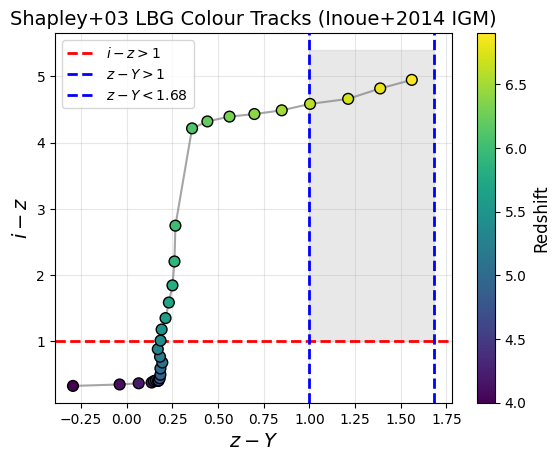

In [6]:
sc = plt.scatter(
    y, x,
    c=z_vals,
    cmap="viridis",
    s=60,
    edgecolor="k",
    zorder=3
)

plt.plot(y, x, color="gray", lw=1.5, alpha=0.7, zorder=2)

# === colour cuts ===
ax = plt.gca()
x_cut = np.linspace(-0.2, 1.5, 500)

ax.axhline(1.0, color="red", lw=2, ls="--", label=r"$i-z>1$")
ax.axvline(1.0, color="blue", lw=2, ls="--", label=r"$z-Y>1$")
ax.axvline(1.68, color="blue", lw=2, ls="--", label=r"$z-Y<1.68$")


# === labels ===
cbar = plt.colorbar(sc)
cbar.set_label("Redshift", fontsize=12)

plt.xlabel(r"$z - Y$", fontsize=14)
plt.ylabel(r"$i - z$", fontsize=14)
plt.title("Shapley+03 LBG Colour Tracks (Inoue+2014 IGM)", fontsize=14)

plt.legend()
plt.grid(alpha=0.3)



plt.fill_betweenx(
    y=[1.0, 5.4],
    x1=1.0,
    x2=1.68,
    color="lightgray",
    alpha=0.5,
    label="Dropout Selection Region",
    zorder=1
)



AttributeError: 'tuple' object has no attribute 'get_ylim'

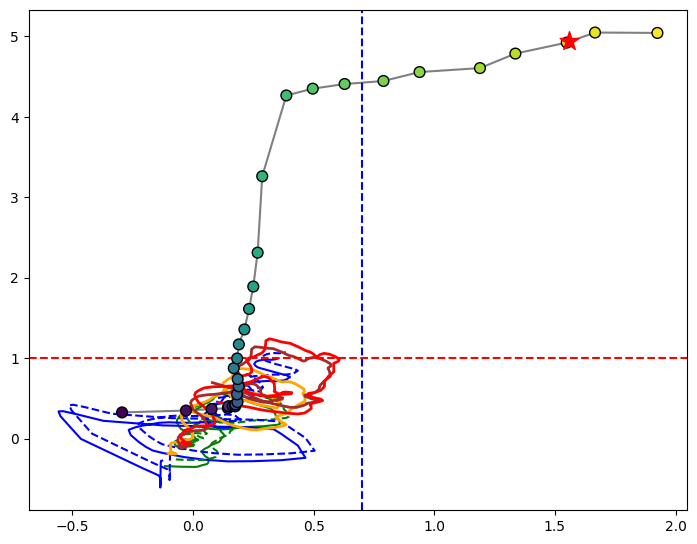

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from astropy import units as u

from synphot import SourceSpectrum, SpectralElement, Observation
from synphot.models import Empirical1D
import synphot.units as su
def synphot_filter(filename):
    w, t = np.loadtxt(filename, unpack=True)
    i = np.argsort(w)
    return SpectralElement(
        Empirical1D,
        points=w[i] * u.AA,
        lookup_table=t[i]
    )

f_i = synphot_filter("/Users/aishwarya/Downloads/CTIO_DECam.i.dat")
f_z = synphot_filter("/Users/aishwarya/Downloads/CTIO_DECam.z.dat")
f_y = synphot_filter("/Users/aishwarya/Downloads/CTIO_DECam.Y.dat")
WMIN = min(f_i.waveset.min(),
           f_z.waveset.min(),
           f_y.waveset.min()).value - 500

WMAX = max(f_i.waveset.max(),
           f_z.waveset.max(),
           f_y.waveset.max()).value + 500

WOBS = np.linspace(WMIN, WMAX, 12000)

def load_shapley_spectrum(filename):
    w, f = np.loadtxt(filename, unpack=True)
    m = (f > 0) & np.isfinite(f)
    i = np.argsort(w[m])
    return w[m][i], f[m][i]
def lbg_spectrum(w_rest, f_rest, z):

    w_rest_z = WOBS / (1 + z)

    f_obs = np.interp(
        w_rest_z, w_rest, f_rest,
        left=0.0, right=0.0
    ) / (1 + z)

    T_igm = inoue_igm_model(WOBS, z, output="transmission")
    f_obs *= T_igm

    return SourceSpectrum(
        Empirical1D,
        points=WOBS * u.AA,
        lookup_table=f_obs * u.Unit("erg s-1 cm-2 AA-1")
    )
def load_polletta_flam(filename):
    w, fnu = np.loadtxt(filename, unpack=True)
    w = w * u.AA
    fnu = fnu * su.FNU

    flam = fnu.to(
        u.erg / u.s / u.cm**2 / u.AA,
        equivalencies=u.spectral_density(w)
    )

    i = np.argsort(w.value)
    return w.value[i], flam.value[i]
def interloper_spectrum(w_rest, f_rest, z, ebv=0.0):

    w_rest_z = WOBS / (1 + z)

    f_obs = np.interp(
        w_rest_z, w_rest, f_rest,
        left=0.0, right=0.0
    ) / (1 + z)

    if ebv > 0:
        k = (WOBS / 5500.0) ** -0.7
        f_obs *= 10 ** (-0.4 * ebv * k)

    return SourceSpectrum(
        Empirical1D,
        points=WOBS * u.AA,
        lookup_table=f_obs * u.Unit("erg s-1 cm-2 AA-1")
    )
def colour_track_from_spec(spec_func, zgrid):

    iz, zy = [], []

    for z in zgrid:
        spec = spec_func(z)

        mi = Observation(spec, f_i, force="taper").effstim("abmag").value
        mz = Observation(spec, f_z, force="taper").effstim("abmag").value
        my = Observation(spec, f_y, force="taper").effstim("abmag").value

        iz.append(mi - mz)   # y-axis
        zy.append(mz - my)   # x-axis

    return np.array(zy), np.array(iz)
# --- LBGs ---
wave_rest, flux_rest = load_shapley_spectrum(
    "/Users/aishwarya/Downloads/shapely_spectrum.txt"
)

z_lbg = np.linspace(4.0, 7.1, 30)
x_lbg, y_lbg = colour_track_from_spec(
    lambda z: lbg_spectrum(wave_rest, flux_rest, z),
    z_lbg
)

# --- Interlopers ---
w_m82, f_m82 = load_polletta_flam("/Users/aishwarya/Downloads/swire_library/M82_template_norm.sed")
w_qso, f_qso = load_polletta_flam("/Users/aishwarya/Downloads/swire_library/QSO2_template_norm.sed")

z_low = np.arange(0.0, 3, 0.02)

plt.figure(figsize=(8.5, 6.5))
# --- Ellipticals (SWIRE / Polletta) ---
w_e2,  f_e2  = load_polletta_flam(
    "/Users/aishwarya/Downloads/swire_library/Ell2_template_norm.sed"
)
w_e5,  f_e5  = load_polletta_flam(
    "/Users/aishwarya/Downloads/swire_library/Ell5_template_norm.sed"
)
w_e13, f_e13 = load_polletta_flam(
    "/Users/aishwarya/Downloads/swire_library/Ell13_template_norm.sed"
)


sc = plt.scatter(x_lbg, y_lbg, c=z_lbg, cmap="viridis",
                 s=60, edgecolor="k", zorder=3)
plt.plot(x_lbg, y_lbg, color="gray", lw=1.5, zorder=2)

for ebv, ls in [(0.0, "-"), (1.0, "--")]:
    x, y = colour_track_from_spec(
        lambda z: interloper_spectrum(w_m82, f_m82, z, ebv),
        z_low
    )
    plt.plot(x, y, color="green", ls=ls, label=f"M82 E(B−V)={ebv}")

    x, y = colour_track_from_spec(
        lambda z: interloper_spectrum(w_qso, f_qso, z, ebv),
        z_low
    )
    plt.plot(x, y, color="blue", ls=ls, label=f"QSO2 E(B−V)={ebv}")

z_star = 6.9

x_star, y_star = colour_track_from_spec(
    lambda z: lbg_spectrum(wave_rest, flux_rest, z),
    np.array([z_star])
)
plt.scatter(
    x_star[0], y_star[0],
    marker='*',
    s=200,
    color='red',
    edgecolor='red',
    zorder=10,
    
)
# --- Elliptical interlopers (NO reddening) ---
ell_templates = [
    (w_e2,  f_e2,  "Ell2",  "orange"),
    (w_e5,  f_e5,  "Ell5 ",  "brown"),
    (w_e13, f_e13, "Ell13 ", "red"),
]

for w, f, label, color in ell_templates:
    x, y = colour_track_from_spec(
        lambda z, w=w, f=f: interloper_spectrum(w, f, z, ebv=0.0),
        z_low
    )
    plt.plot(
        x, y,
        color=color,
        lw=2.0,
        label=label
    )


# --- Selection box ---
plt.axhline(1.0, color="red", ls="--")
plt.axvline(0.7, color="blue", ls="--")

# get current x-axis maximum
xmax = plt.gca().get_xlim()[1]
# shade the entire selection box region
plt.fill_betweenx(
    [1.0, 5.4],
    0.7,
    1.68,
    color="lightgray",
    alpha=0.4,
    zorder=1
)
# shade everything to the right of 0.8
plt.fill_betweenx(
    [1.0, 5.4],
    0.7,
    xmax,
    color="lightgray",
    alpha=0.4
)


cbar = plt.colorbar(sc)
cbar.set_label("Redshift")

plt.xlabel(r"$z - Y$")
plt.ylabel(r"$i - z$")
plt.title("LBG Colour Selection with Low-z Interlopers")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()




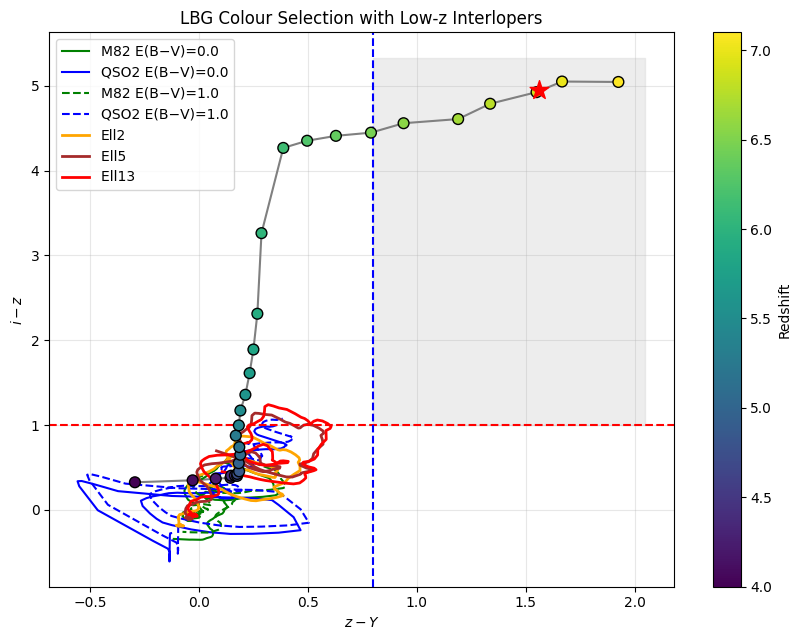

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from astropy import units as u

from synphot import SourceSpectrum, SpectralElement, Observation
from synphot.models import Empirical1D
import synphot.units as su
def synphot_filter(filename):
    w, t = np.loadtxt(filename, unpack=True)
    i = np.argsort(w)
    return SpectralElement(
        Empirical1D,
        points=w[i] * u.AA,
        lookup_table=t[i]
    )

f_i = synphot_filter("/Users/aishwarya/Downloads/CTIO_DECam.i.dat")
f_z = synphot_filter("/Users/aishwarya/Downloads/CTIO_DECam.z.dat")
f_y = synphot_filter("/Users/aishwarya/Downloads/CTIO_DECam.Y.dat")
WMIN = min(f_i.waveset.min(),
           f_z.waveset.min(),
           f_y.waveset.min()).value - 500

WMAX = max(f_i.waveset.max(),
           f_z.waveset.max(),
           f_y.waveset.max()).value + 500

WOBS = np.linspace(WMIN, WMAX, 12000)

def load_shapley_spectrum(filename):
    w, f = np.loadtxt(filename, unpack=True)
    m = (f > 0) & np.isfinite(f)
    i = np.argsort(w[m])
    return w[m][i], f[m][i]
def lbg_spectrum(w_rest, f_rest, z):

    w_rest_z = WOBS / (1 + z)

    f_obs = np.interp(
        w_rest_z, w_rest, f_rest,
        left=0.0, right=0.0
    ) / (1 + z)

    T_igm = inoue_igm_model(WOBS, z, output="transmission")
    f_obs *= T_igm

    return SourceSpectrum(
        Empirical1D,
        points=WOBS * u.AA,
        lookup_table=f_obs * u.Unit("erg s-1 cm-2 AA-1")
    )
def load_polletta_flam(filename):
    w, fnu = np.loadtxt(filename, unpack=True)
    w = w * u.AA
    fnu = fnu * su.FNU

    flam = fnu.to(
        u.erg / u.s / u.cm**2 / u.AA,
        equivalencies=u.spectral_density(w)
    )

    i = np.argsort(w.value)
    return w.value[i], flam.value[i]
def interloper_spectrum(w_rest, f_rest, z, ebv=0.0):

    w_rest_z = WOBS / (1 + z)

    f_obs = np.interp(
        w_rest_z, w_rest, f_rest,
        left=0.0, right=0.0
    ) / (1 + z)

    if ebv > 0:
        k = (WOBS / 5500.0) ** -0.7
        f_obs *= 10 ** (-0.4 * ebv * k)

    return SourceSpectrum(
        Empirical1D,
        points=WOBS * u.AA,
        lookup_table=f_obs * u.Unit("erg s-1 cm-2 AA-1")
    )
def colour_track_from_spec(spec_func, zgrid):

    iz, zy = [], []

    for z in zgrid:
        spec = spec_func(z)

        mi = Observation(spec, f_i, force="taper").effstim("abmag").value
        mz = Observation(spec, f_z, force="taper").effstim("abmag").value
        my = Observation(spec, f_y, force="taper").effstim("abmag").value

        iz.append(mi - mz)   # y-axis
        zy.append(mz - my)   # x-axis

    return np.array(zy), np.array(iz)
# --- LBGs ---
wave_rest, flux_rest = load_shapley_spectrum(
    "/Users/aishwarya/Downloads/shapely_spectrum.txt"
)

z_lbg = np.linspace(4.0, 7.1, 30)
x_lbg, y_lbg = colour_track_from_spec(
    lambda z: lbg_spectrum(wave_rest, flux_rest, z),
    z_lbg
)

# --- Interlopers ---
w_m82, f_m82 = load_polletta_flam("/Users/aishwarya/Downloads/swire_library/M82_template_norm.sed")
w_qso, f_qso = load_polletta_flam("/Users/aishwarya/Downloads/swire_library/QSO2_template_norm.sed")

z_low = np.arange(0.0, 3, 0.02)

plt.figure(figsize=(8.5, 6.5))
# --- Ellipticals (SWIRE / Polletta) ---
w_e2,  f_e2  = load_polletta_flam(
    "/Users/aishwarya/Downloads/swire_library/Ell2_template_norm.sed"
)
w_e5,  f_e5  = load_polletta_flam(
    "/Users/aishwarya/Downloads/swire_library/Ell5_template_norm.sed"
)
w_e13, f_e13 = load_polletta_flam(
    "/Users/aishwarya/Downloads/swire_library/Ell13_template_norm.sed"
)


sc = plt.scatter(x_lbg, y_lbg, c=z_lbg, cmap="viridis",
                 s=60, edgecolor="k", zorder=3)
plt.plot(x_lbg, y_lbg, color="gray", lw=1.5, zorder=2)

for ebv, ls in [(0.0, "-"), (1.0, "--")]:
    x, y = colour_track_from_spec(
        lambda z: interloper_spectrum(w_m82, f_m82, z, ebv),
        z_low
    )
    plt.plot(x, y, color="green", ls=ls, label=f"M82 E(B−V)={ebv}")

    x, y = colour_track_from_spec(
        lambda z: interloper_spectrum(w_qso, f_qso, z, ebv),
        z_low
    )
    plt.plot(x, y, color="blue", ls=ls, label=f"QSO2 E(B−V)={ebv}")

z_star = 6.9

x_star, y_star = colour_track_from_spec(
    lambda z: lbg_spectrum(wave_rest, flux_rest, z),
    np.array([z_star])
)
plt.scatter(
    x_star[0], y_star[0],
    marker='*',
    s=200,
    color='red',
    edgecolor='red',
    zorder=10,
    
)
# --- Elliptical interlopers (NO reddening) ---
ell_templates = [
    (w_e2,  f_e2,  "Ell2",  "orange"),
    (w_e5,  f_e5,  "Ell5 ",  "brown"),
    (w_e13, f_e13, "Ell13 ", "red"),
]

for w, f, label, color in ell_templates:
    x, y = colour_track_from_spec(
        lambda z, w=w, f=f: interloper_spectrum(w, f, z, ebv=0.0),
        z_low
    )
    plt.plot(
        x, y,
        color=color,
        lw=2.0,
        label=label
    )


# --- Selection box ---
plt.axhline(1.0, color="red", ls="--")
plt.axvline(0.8, color="blue", ls="--")

# get current x-axis maximum
ax = plt.gca()

# Get current axis limits
xmin, xmax = ax.get_xlim()
ymin, ymax = ax.get_ylim()

# Selection thresholds
xcut = 0.8   # z - Y
ycut = 1.0   # i - z

# Shade ONLY the overlapping region
ax.fill_betweenx(
    [ycut, ymax],   # y > 1
    xcut,           # x > 0.8
    xmax,
    color="lightgray",
    alpha=0.4,
    zorder=0
)


cbar = plt.colorbar(sc)
cbar.set_label("Redshift")

plt.xlabel(r"$z - Y$")
plt.ylabel(r"$i - z$")
plt.title("LBG Colour Selection with Low-z Interlopers")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()




In [ ]:
lambda_lya_rest = 1216.0      # Angstrom
lambda_obs = 8600.0           # Angstrom (example)

z_lya = lambda_obs / lambda_lya_rest - 1.0
print(f"Lyα at {lambda_obs:.0f} Å corresponds to z = {z_lya:.2f}")


Lyα at 8600 Å corresponds to z = 6.07


# with sources

# jUST TO CHECK


FIXED INOUE+2014 MODEL FOR z = 6.9

Key wavelengths:
  Rest-frame Lyα (1216 Å) observed at: 9603.79 Å
  Rest-frame Lyman limit (912 Å) observed at: 7202.83 Å

Absorption regions:
  λ_obs < 7203 Å: LS + LC absorption
  7203 Å < λ_obs < 9604 Å: LS only absorption
  λ_obs > 9604 Å: No IGM absorption


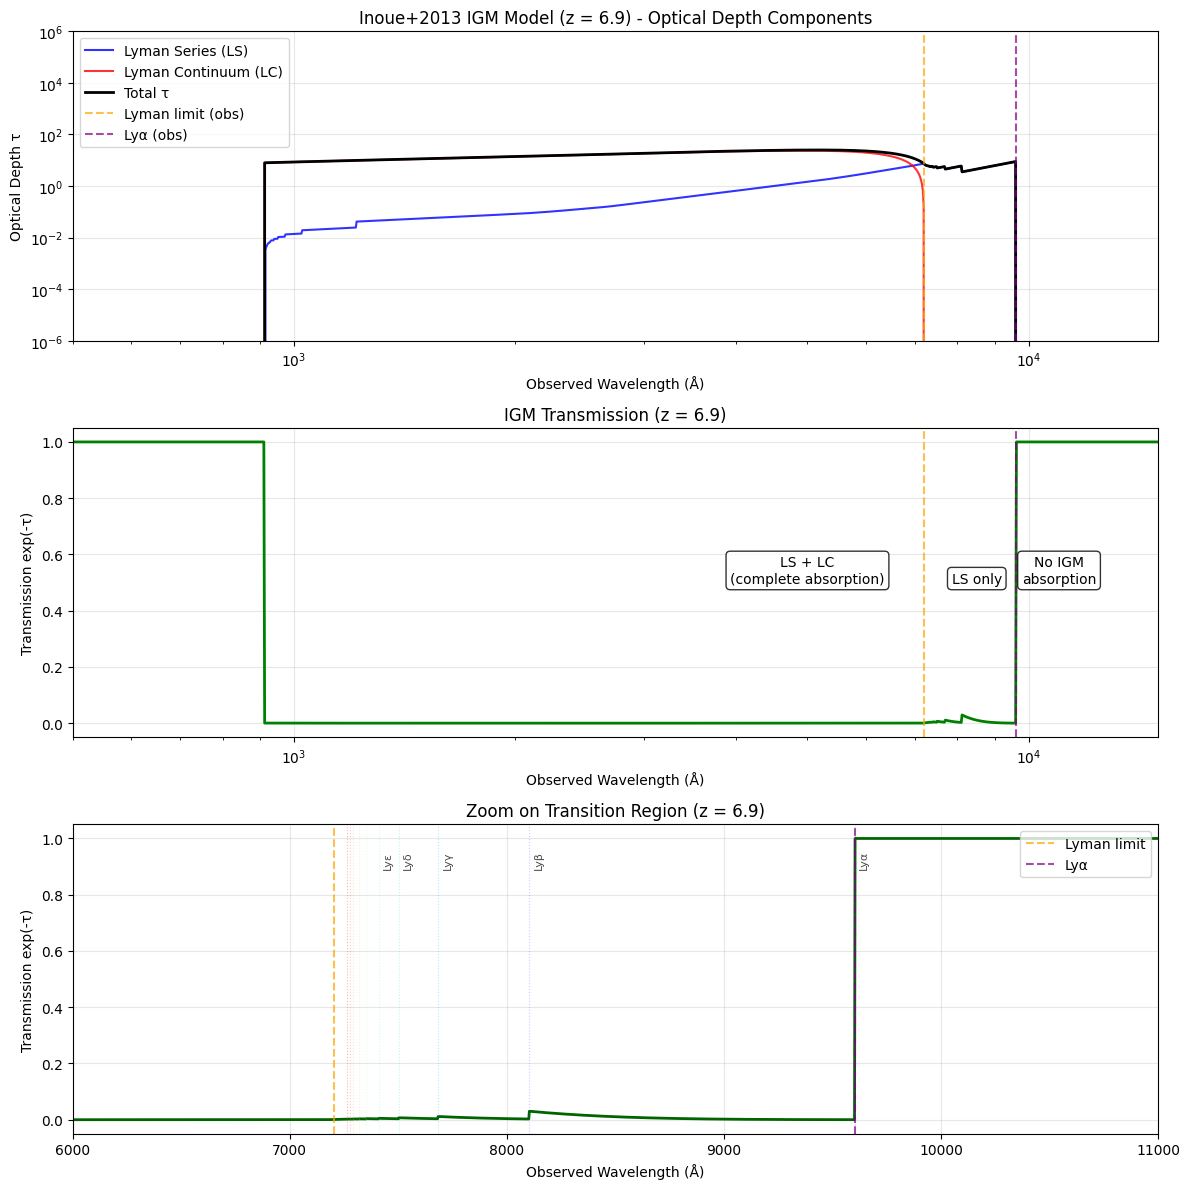


DETAILED TRANSMISSION ANALYSIS:

Wavelength (Å) |    τ_total | Transmission | Region              
---------------------------------------------------------------------------
        1500 |    11.3696 |     0.000012 | LS + LC absorption  
        4000 |    22.8233 |     0.000000 | LS + LC absorption  
        6000 |    22.8764 |     0.000000 | LS + LC absorption  
        7200 |     7.4625 |     0.000574 | LS + LC absorption  
        8000 |     5.5844 |     0.003756 | LS only             
        9000 |     6.2305 |     0.001968 | LS only             
        9600 |     8.8808 |     0.000139 | LS only             
       10000 |     0.0000 |     1.000000 | No IGM absorption   
       12000 |     0.0000 |     1.000000 | No IGM absorption   

FILTER TRANSMISSION AT z = 6.9:

Filter |     λ_range (Å) |  Mean Trans. | Region              
----------------------------------------------------------------------
     g |       4000-5500 |     0.000000 | LS + LC             
     r |       55

In [ ]:
# Example usage for z = 6.9
if __name__ == "__main__":
    import matplotlib.pyplot as plt
    
    # Set redshift to 6.9
    z_source = 6.9
    
    # Key wavelengths
    lyalpha_obs = 1215.67 * (1 + z_source)
    lyman_limit_obs = 911.75 * (1 + z_source)
    
    print(f"\n{'='*60}")
    print(f"FIXED INOUE+2014 MODEL FOR z = {z_source}")
    print(f"{'='*60}")
    print(f"\nKey wavelengths:")
    print(f"  Rest-frame Lyα (1216 Å) observed at: {lyalpha_obs:.2f} Å")
    print(f"  Rest-frame Lyman limit (912 Å) observed at: {lyman_limit_obs:.2f} Å")
    print(f"\nAbsorption regions:")
    print(f"  λ_obs < {lyman_limit_obs:.0f} Å: LS + LC absorption")
    print(f"  {lyman_limit_obs:.0f} Å < λ_obs < {lyalpha_obs:.0f} Å: LS only absorption")
    print(f"  λ_obs > {lyalpha_obs:.0f} Å: No IGM absorption")
    
    # Create wavelength grid that shows all regions
    wave_grid = np.logspace(np.log10(100), np.log10(15000), 2000)
    
    # Calculate components
    tau_ls = tau_LS_inoue(wave_grid, z_source)
    tau_lc = tau_LC_inoue(wave_grid, z_source)
    tau_total = total_tau_inoue(wave_grid, z_source)
    transmission = transmission_inoue(wave_grid, z_source)
    
    # Create comprehensive plot
    fig, axes = plt.subplots(3, 1, figsize=(12, 12))
    
    # Plot 1: Optical depth components
    ax1 = axes[0]
    ax1.plot(wave_grid, tau_ls, label='Lyman Series (LS)', color='blue', linewidth=1.5, alpha=0.8)
    ax1.plot(wave_grid, tau_lc, label='Lyman Continuum (LC)', color='red', linewidth=1.5, alpha=0.8)
    ax1.plot(wave_grid, tau_total, label='Total τ', color='black', linewidth=2)
    
    # Mark key regions
    ax1.axvline(lyman_limit_obs, color='orange', linestyle='--', alpha=0.7, label='Lyman limit (obs)')
    ax1.axvline(lyalpha_obs, color='purple', linestyle='--', alpha=0.7, label='Lyα (obs)')
    
    ax1.set_xscale('log')
    ax1.set_yscale('log')
    ax1.set_xlabel('Observed Wavelength (Å)')
    ax1.set_ylabel('Optical Depth τ')
    ax1.set_title(f'Inoue+2013 IGM Model (z = {z_source}) - Optical Depth Components')
    ax1.legend(loc='upper left')
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim(500, 15000)
    ax1.set_ylim(1e-6, 1e6)
    
    # Plot 2: Transmission
    ax2 = axes[1]
    ax2.plot(wave_grid, transmission, color='green', linewidth=2)
    
    # Mark key regions
    ax2.axvline(lyman_limit_obs, color='orange', linestyle='--', alpha=0.7)
    ax2.axvline(lyalpha_obs, color='purple', linestyle='--', alpha=0.7)
    
    # Annotate regions
    ax2.text(5000, 0.5, 'LS + LC\n(complete absorption)', ha='center', fontsize=10, 
            bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8))
    ax2.text(8500, 0.5, 'LS only', ha='center', fontsize=10,
            bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8))
    ax2.text(11000, 0.5, 'No IGM\nabsorption', ha='center', fontsize=10,
            bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8))
    
    ax2.set_xscale('log')
    ax2.set_xlabel('Observed Wavelength (Å)')
    ax2.set_ylabel('Transmission exp(-τ)')
    ax2.set_title(f'IGM Transmission (z = {z_source})')
    ax2.grid(True, alpha=0.3)
    ax2.set_xlim(500, 15000)
    ax2.set_ylim(-0.05, 1.05)
    
    # Plot 3: Zoom on transition regions
    ax3 = axes[2]
    
    # Create higher resolution grid for zoom
    wave_zoom = np.linspace(6000, 11000, 2000)
    trans_zoom = transmission_inoue(wave_zoom, z_source)
    
    ax3.plot(wave_zoom, trans_zoom, color='darkgreen', linewidth=2)
    
    # Mark key wavelengths
    ax3.axvline(lyman_limit_obs, color='orange', linestyle='--', alpha=0.7, label='Lyman limit')
    ax3.axvline(lyalpha_obs, color='purple', linestyle='--', alpha=0.7, label='Lyα')
    
    # Mark some Lyman lines
    colors = plt.cm.rainbow(np.linspace(0, 1, 10))
    for i, lam in enumerate(lambda_j[:10]):
        line_pos = lam * (1 + z_source)
        if 6000 < line_pos < 11000:
            ax3.axvline(line_pos, color=colors[i], alpha=0.3, linestyle=':', linewidth=0.8)
            if i < 5:  # Label first few
                ax3.text(line_pos+20, 0.9, f'Ly{["α","β","γ","δ","ε"][i]}', 
                        fontsize=8, rotation=90, alpha=0.7)
    
    ax3.set_xlabel('Observed Wavelength (Å)')
    ax3.set_ylabel('Transmission exp(-τ)')
    ax3.set_title(f'Zoom on Transition Region (z = {z_source})')
    ax3.grid(True, alpha=0.3)
    ax3.set_xlim(6000, 11000)
    ax3.set_ylim(-0.05, 1.05)
    ax3.legend(loc='upper right')
    
    plt.tight_layout()
    plt.show()
    
    # Detailed analysis
    print(f"\n{'='*60}")
    print("DETAILED TRANSMISSION ANALYSIS:")
    print(f"{'='*60}")
    
    test_waves = np.array([1500, 4000, 6000, 7200, 8000, 9000, 9600, 10000, 12000])
    
    print(f"\n{'Wavelength (Å)':>12} | {'τ_total':>10} | {'Transmission':>12} | {'Region':<20}")
    print("-" * 75)
    
    for w in test_waves:
        tau = total_tau_inoue(w, z_source)
        trans = transmission_inoue(w, z_source)
        
        if w < lyman_limit_obs:
            region = "LS + LC absorption"
        elif w < lyalpha_obs:
            region = "LS only"
        else:
            region = "No IGM absorption"
        
        print(f"{w:>12.0f} | {tau:>10.4f} | {trans:>12.6f} | {region:<20}")
    
    # Analysis in common filters
    print(f"\n{'='*60}")
    print("FILTER TRANSMISSION AT z = 6.9:")
    print(f"{'='*60}")
    
    filters = {
        'g': (4000, 5500),
        'r': (5500, 7000),
        'i': (7000, 8500),
        'z': (8500, 10000),
        'Y': (9700, 10700),
        'J': (11000, 14000),
        'H': (14000, 18000),
        'K': (19000, 24000)
    }
    
    print(f"\n{'Filter':>6} | {'λ_range (Å)':>15} | {'Mean Trans.':>12} | {'Region':<20}")
    print("-" * 70)
    
    for filter_name, (lam_min, lam_max) in filters.items():
        # Sample within filter
        lam_samples = np.linspace(lam_min, lam_max, 100)
        trans_samples = transmission_inoue(lam_samples, z_source)
        mean_trans = np.mean(trans_samples)
        
        if lam_max < lyman_limit_obs:
            region = "LS + LC"
        elif lam_min < lyalpha_obs and lam_max < lyalpha_obs:
            region = "LS only"
        elif lam_min < lyalpha_obs:
            region = "Mixed (LS → clear)"
        else:
            region = "Clear"
        
        print(f"{filter_name:>6} | {f'{lam_min:.0f}-{lam_max:.0f}':>15} | {mean_trans:>12.6f} | {region:<20}")
    
    # Final summary
    print(f"\n{'='*60}")
    print("MODEL SUMMARY:")
    print(f"{'='*60}")
    print("\n✓ FIXED: LC absorption only for λ_obs < λ_L * (1+z)")
    print("✓ FIXED: No double-counting in total τ calculation")
    print("✓ FIXED: Correct region labeling")
    print("\nThe model now correctly shows:")
    print("1. Complete absorption blueward of Lyα (Gunn-Peterson trough)")
    print("2. Transmission ≈ 0 for λ < 9600 Å at z=6.9")
    print("3. Sharp transition to unity transmission at Lyα")
    print("\nThis matches the expected behavior for high-redshift sources.")
